# Actividad Individual Data Wrangling - PARTE A

**Angel Irwin Briseño Fierro A01796844**

En esta practica se realizara el EDA y proceso de limpieza de los datasets provistos "room-occupancy-estimation", original y modificado, con la finalidad de obtener una comparacion tal que evidencie la influencia de estos procesos en los datos y que pueden repercutir en procesos mas adelante en el desarrollo de modelos de ML.

## Dataset original

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
import json
from pathlib import Path

In [3]:
# ogDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\original.csv',dtype=str, keep_default_na=False)
ogDf = pd.read_csv('./original.csv',dtype=str, keep_default_na=False)
ogDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769230769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646153846154,0,0,1
2,2017/12/22,10:50:42,25.0,24.75,24.5,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519230769231,0,0,1
3,2017/12/22,10:51:13,25.0,24.75,24.56,25.44,121,34,53,40,0.41,0.1,0.1,0.09,390,0.388461538462,0,0,1
4,2017/12/22,10:51:44,25.0,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846153846,0,0,1


In [3]:
ogDf.describe().T

,count,unique,top,freq
Date,10129,7,2017/12/23,2779
Time,10129,10129,10:49:41,1
S1_Temp,10129,24,25.44,1132
S2_Temp,10129,69,25.44,1389
S3_Temp,10129,29,24.56,812
S4_Temp,10129,27,25.75,728
S1_Light,10129,68,0,5845
S2_Light,10129,82,0,5846
S3_Light,10129,177,0,5591
S4_Light,10129,75,0,5599


In [4]:
print(f"Rows: {ogDf.shape[0]:,}")
print(f"Columns: {ogDf.shape[1]}")

# Compact data-quality summary
data_quality = pd.DataFrame({
    "dtype": ogDf.dtypes,
    "missing": ogDf.isna().sum(),
    "missing_pct": ogDf.isna().mean() * 100,
    "n_unique": ogDf.nunique()
})

data_quality.sort_values("missing_pct", ascending=False)

Rows: 10,129
Columns: 19


,dtype,missing,missing_pct,n_unique
Date,object,0,0.0,7
Time,object,0,0.0,10129
S1_Temp,object,0,0.0,24
S2_Temp,object,0,0.0,69
S3_Temp,object,0,0.0,29
S4_Temp,object,0,0.0,27
S1_Light,object,0,0.0,68
S2_Light,object,0,0.0,82
S3_Light,object,0,0.0,177
S4_Light,object,0,0.0,75


In [5]:
n_duplicates = ogDf.duplicated().sum()
duplicate_pct = 100 * n_duplicates / len(ogDf)

print(f"Duplicated rows: {n_duplicates:,}")
print(f"Percentage of duplicated rows: {duplicate_pct:.2f}%")

Duplicated rows: 0
Percentage of duplicated rows: 0.00%


In [6]:
exclude = ["Date", "Time"]

for col in ogDf.columns:
    if col not in exclude:
        ogDf[col] = pd.to_numeric(ogDf[col], errors="coerce")
        
numeric_features = [
    col for col in ogDf.select_dtypes(include=np.number).columns
    if col != "Room_Occupancy_Count"
]

univariate_summary = ogDf[numeric_features].describe().T

univariate_summary["median"] = ogDf[numeric_features].median()
univariate_summary["skewness"] = ogDf[numeric_features].skew()
univariate_summary["kurtosis"] = ogDf[numeric_features].kurt()

univariate_summary[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max",
     "skewness", "kurtosis"]
].sort_values("skewness", key=lambda x: x.abs(), ascending=False)

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
S4_Sound,10129.0,0.103840,0.08,0.120683,0.050000,0.060000,0.08,0.10,3.400000,10.952134,211.172069
S2_Sound,10129.0,0.120066,0.05,0.266503,0.040000,0.050000,0.05,0.06,3.440000,6.881610,62.472799
S3_Sound,10129.0,0.158119,0.06,0.413637,0.040000,0.060000,0.06,0.07,3.670000,5.994767,39.477822
S1_Sound,10129.0,0.168178,0.08,0.316709,0.060000,0.070000,0.08,0.08,3.880000,5.450448,39.415196
S7_PIR,10129.0,0.079574,0.00,0.270645,0.000000,0.000000,0.00,0.00,1.000000,3.107460,7.657822
S6_PIR,10129.0,0.090137,0.00,0.286392,0.000000,0.000000,0.00,0.00,1.000000,2.862811,6.196913
S2_Light,10129.0,26.016290,0.00,67.304170,0.000000,0.000000,0.00,14.00,258.000000,2.827817,6.187379
S2_Temp,10129.0,25.546059,25.38,0.586325,24.750000,25.190000,25.38,25.63,29.000000,2.355681,6.506295
S3_Light,10129.0,34.248494,0.00,58.400744,0.000000,0.000000,0.00,50.00,280.000000,2.100069,3.885540
S5_CO2,10129.0,460.860401,360.00,199.964940,345.000000,355.000000,360.00,465.00,1270.000000,1.975692,3.001375


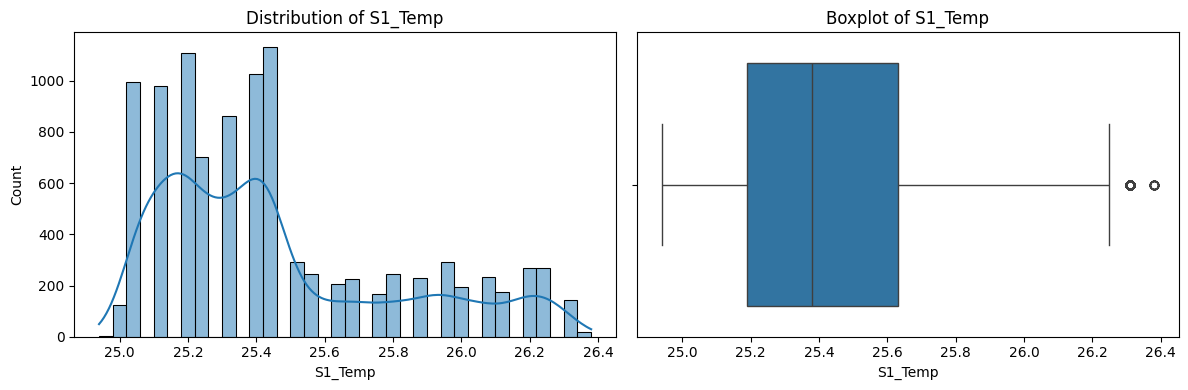

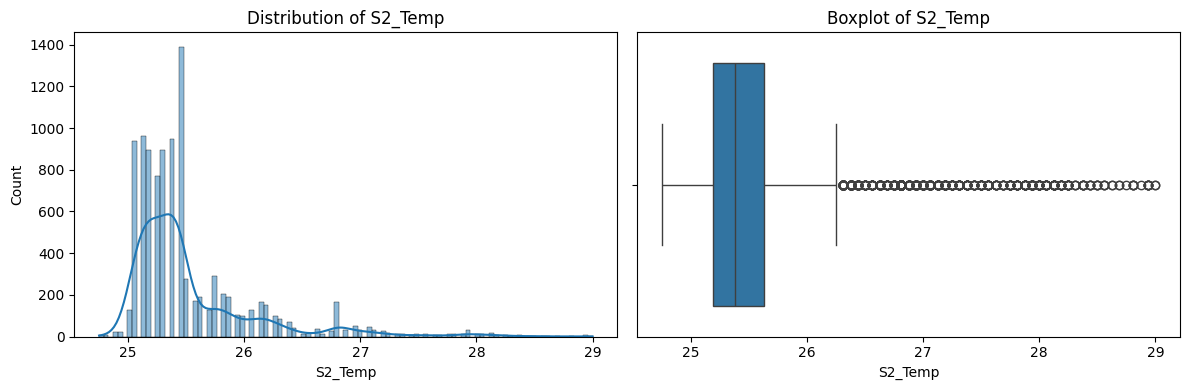

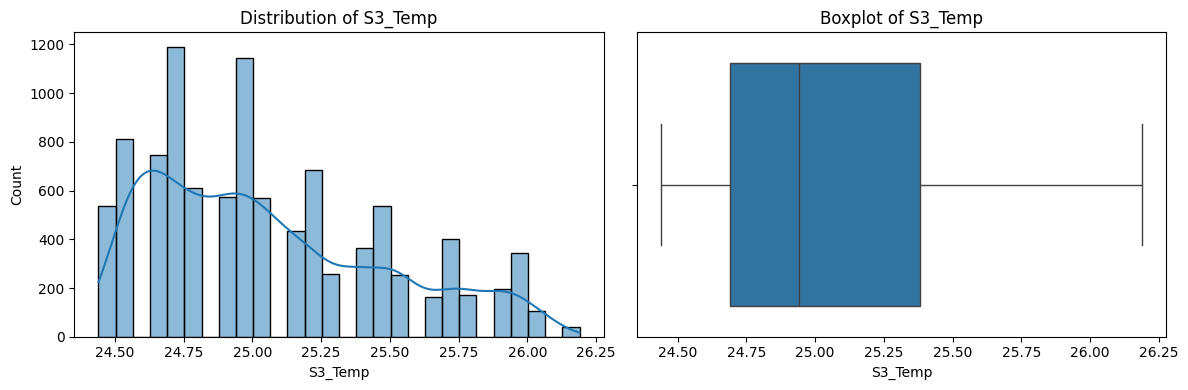

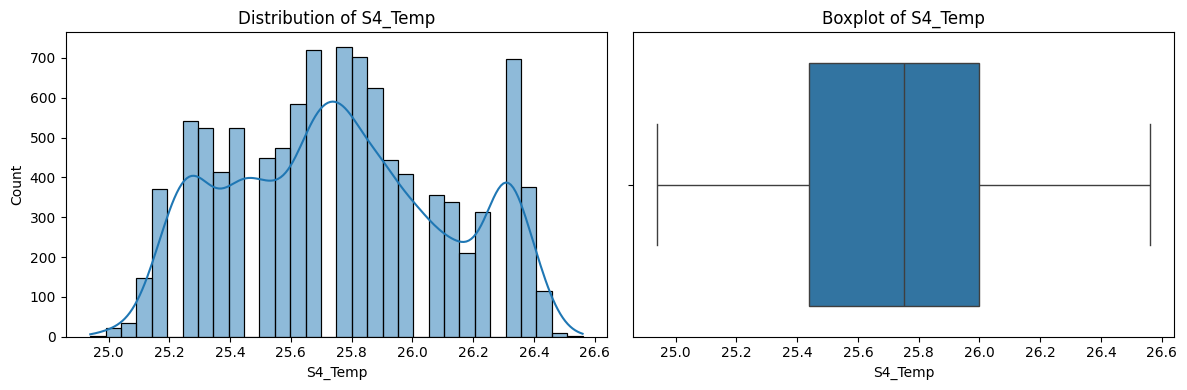

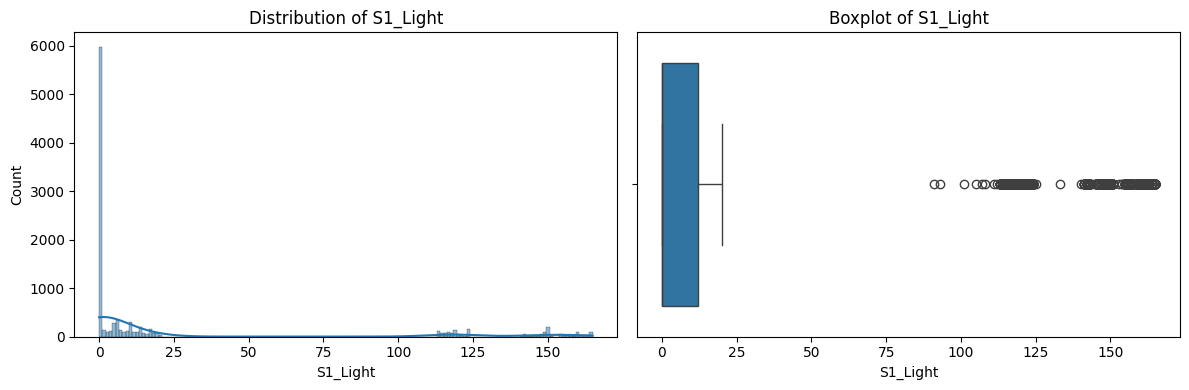

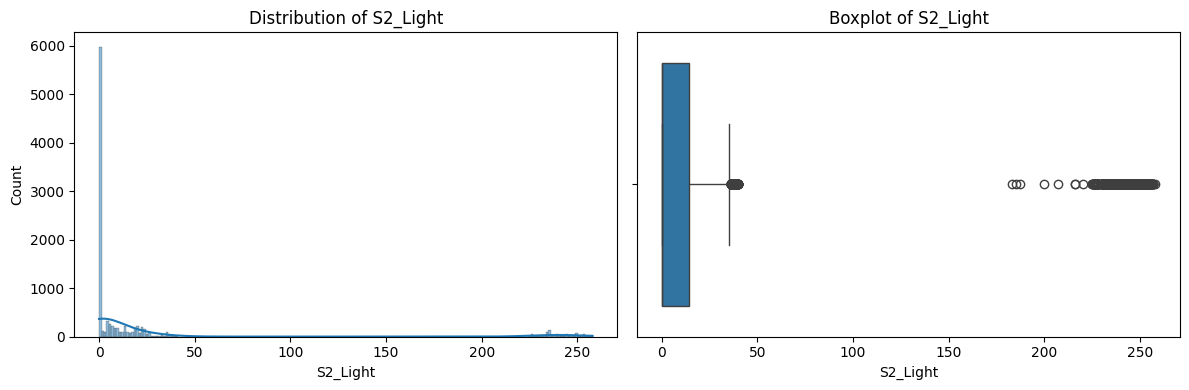

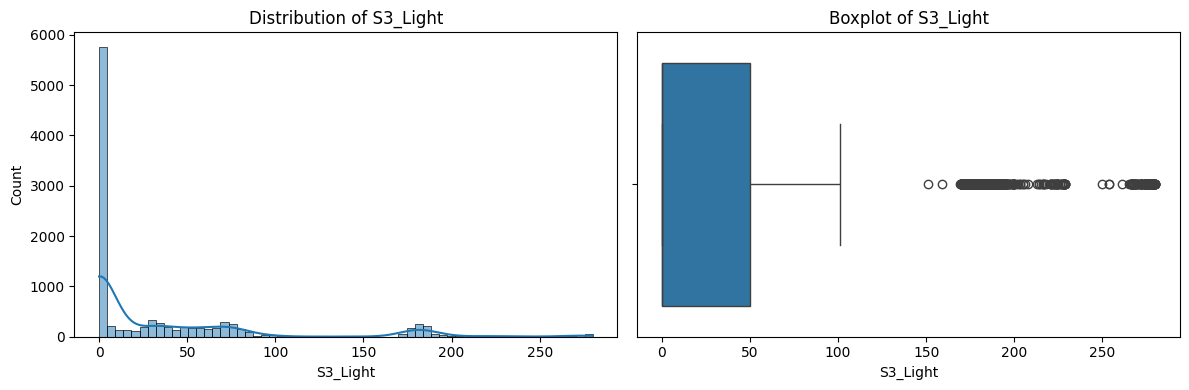

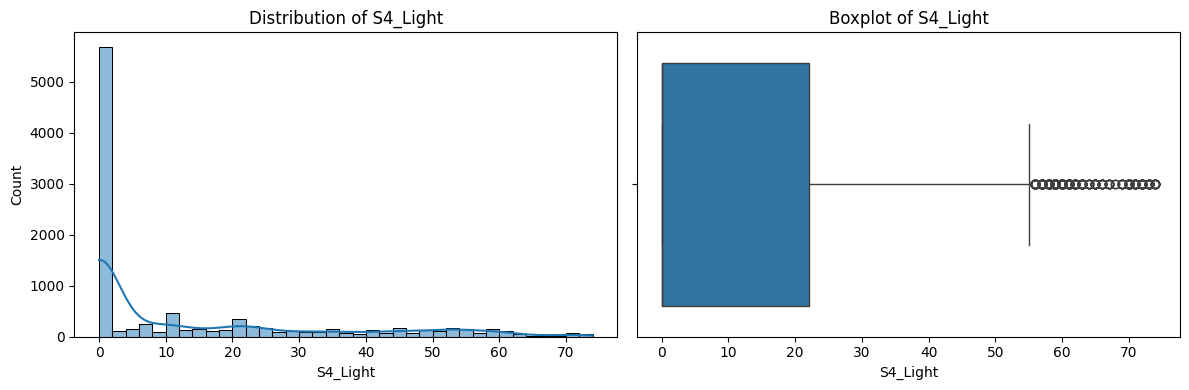

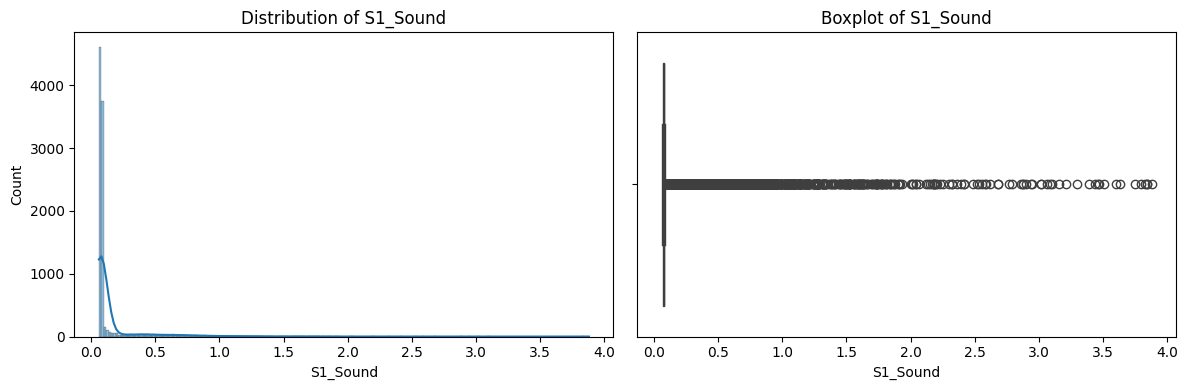

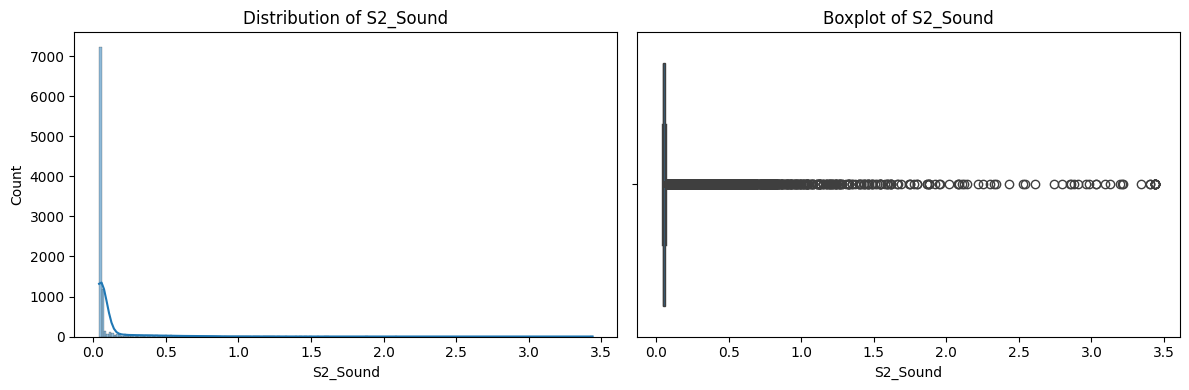

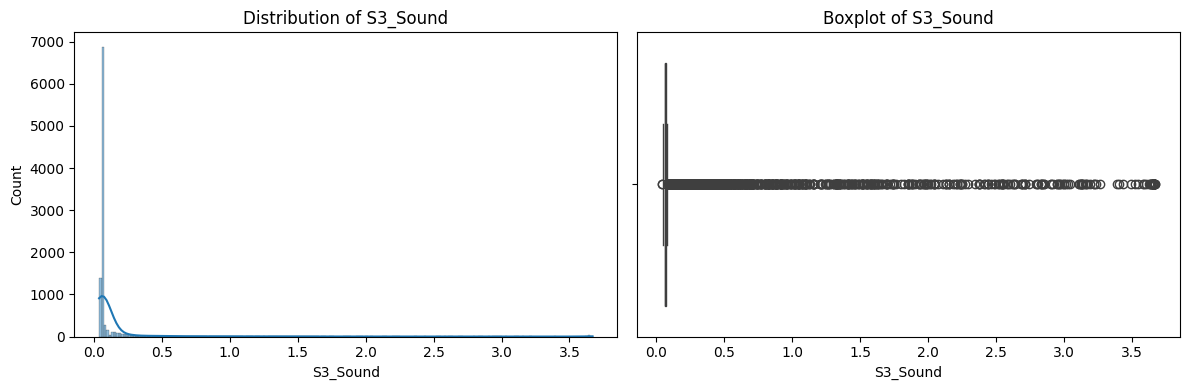

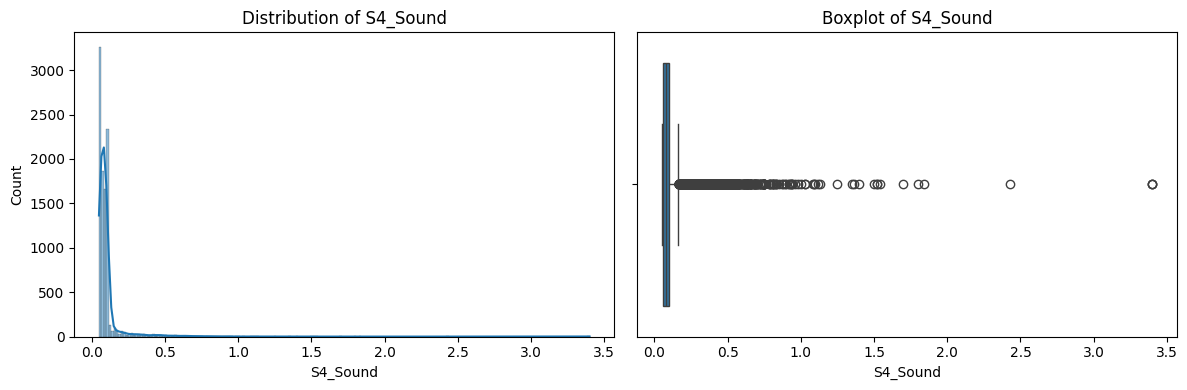

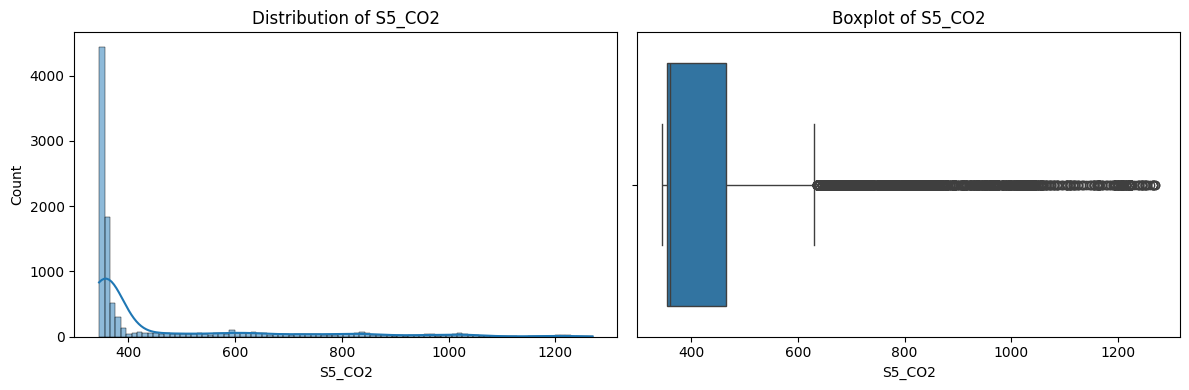

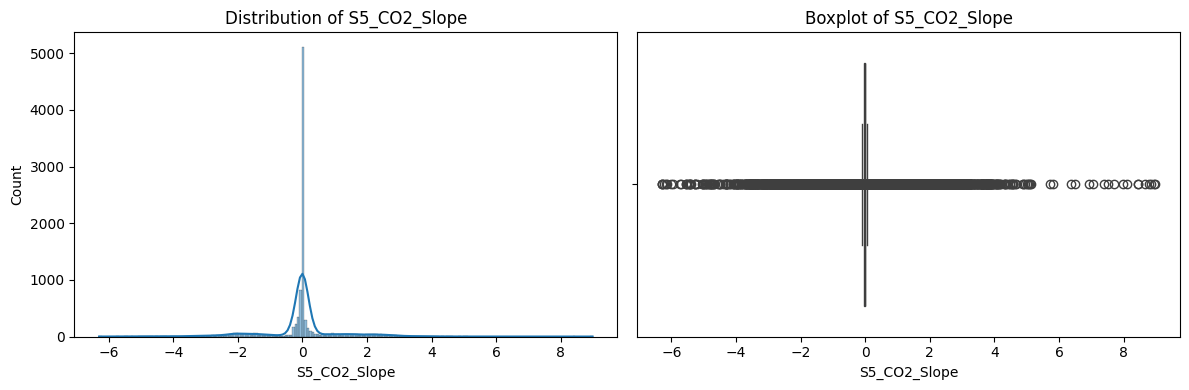

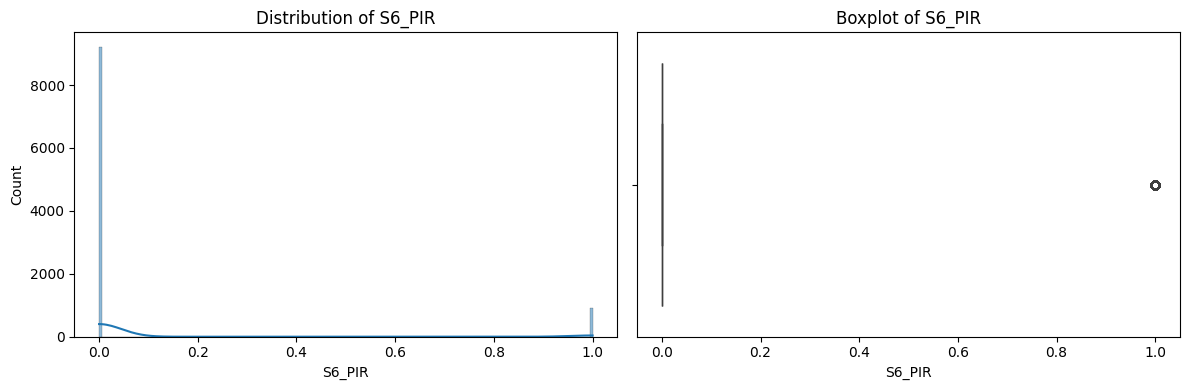

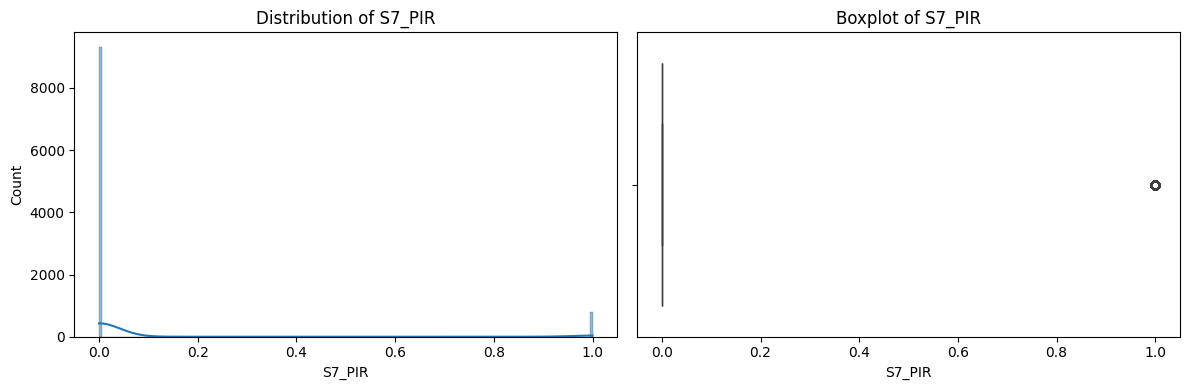

In [7]:
# Distribution + boxplot for every numerical predictor
for column in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=ogDf,
        x=column,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {column}")

    sns.boxplot(
        data=ogDf,
        x=column,
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

**Análisis de la variable objetivo**

Con base en los datos presentados, la variable room_ocupancy_count puede ser utilizada como variable objetivo.
Al verificar las clases, se puede observar un gran desbalance en las variables, la clase 0 (sin ser ocupados) ocupa mas del 80% mas de los registros. 

In [8]:
quality_summary = pd.DataFrame({
    "count": ogDf["Room_Occupancy_Count"].value_counts().sort_index(),
    "percentage": ogDf["Room_Occupancy_Count"].value_counts(normalize=True).sort_index() * 100
})

quality_summary

,count,percentage
Room_Occupancy_Count,,
0,8228,81.232106
1,459,4.531543
2,748,7.384737
3,694,6.851614


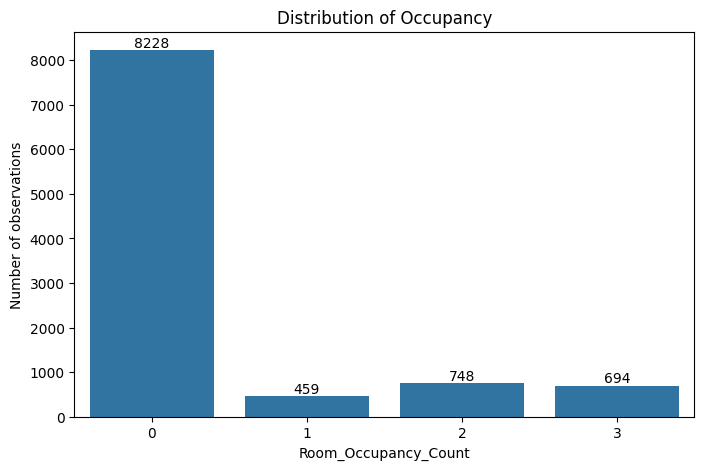

In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=ogDf, x="Room_Occupancy_Count")

plt.title("Distribution of Occupancy")
plt.xlabel("Room_Occupancy_Count")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Dataset modificado

In [4]:
# metadata = json.loads(Path(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\metadata.json').read_text())
metadata = json.loads(Path('./metadata.json').read_text())
print(metadata['rates'])

{'dup_rate': 0.02, 'nan_rate': 0.01, 'outlier_rate': 0.01, 'bad_token_rate': 0.005, 'obj_noise_rate': 0.05, 'add_mixed_type': True}


In [5]:
# ogDf = pd.read_csv(r'D:\Master\MLops\A03_Data_Cleaning_EDA\room-occupancy-estimation\modified.csv')
ogDf = pd.read_csv('./modified.csv')
ogDf.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,mixed_type_col
0,2017/12/22,10:49:41,24.94,345.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769230769231,0.0,0.0,1.0,599
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646153846154,0.0,0.0,1.0,NaN
2,2017/12/22,10:50:42,25.0,24.75,24.5,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519230769231,0.0,0.0,1.0,unknown
3,2017/12/22,10:51:13,25.0,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.1,0.1,0.09,390.0,0.388461538462,0.0,0.0,1.0,584
4,2017/12/22,10:51:44,25.0,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846153846,0.0,0.0,1.0,bad
